# Week 6: HealthConnect Clinic — Model Improvement, Error Analysis & Validation

## Data Science Track

This notebook builds directly on the Week 5 baseline. The Week 5 
pipeline (data preparation, feature engineering, train/test split, and 
baseline model) is reproduced below to establish a self-contained 
starting point, before moving into new Week 6 work: error analysis, 
feature refinement, and model improvement.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\HP\Downloads\HealthConnect_Appointment_Data.csv")

# Exclude Cancelled, encode binary target
df_model = df[df['appointment_outcome'] != 'Cancelled'].copy()
df_model['target_no_show'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)

# Drop irrelevant/leakage columns
df_model = df_model.drop(columns=[
    'appointment_id', 'booking_date', 'appointment_date',
    'waiting_time_minutes', 'appointment_outcome'
])

# Handle missing values
df_model['reminder_channel'] = df_model['reminder_channel'].fillna('None')
median_distance = df_model['distance_to_clinic_km'].median()
df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(median_distance)

print("df_model shape:", df_model.shape)

df_model shape: (4737, 14)


In [2]:
# Feature engineering (from Week 5)
df_model['prior_no_show_rate'] = np.where(
    df_model['previous_appointments'] > 0,
    df_model['previous_no_shows'] / df_model['previous_appointments'],
    0
)

def categorize_lead_time(days):
    if days <= 7:
        return 'Short'
    elif days <= 30:
        return 'Medium'
    else:
        return 'Long'

df_model['booking_lead_category'] = df_model['booking_lead_days'].apply(categorize_lead_time)
df_model['has_prior_history'] = (df_model['previous_appointments'] > 0).astype(int)

print("Feature engineering complete. Shape:", df_model.shape)

Feature engineering complete. Shape: (4737, 17)


In [3]:
# Encode categorical variables
categorical_cols_final = ['gender', 'age_group', 'appointment_type', 'appointment_day',
                           'appointment_time', 'reminder_sent', 'reminder_channel',
                           'booking_lead_category']

df_encoded = pd.get_dummies(df_model, columns=categorical_cols_final, drop_first=True)

print("Encoded shape:", df_encoded.shape)

Encoded shape: (4737, 33)


In [4]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=['patient_id', 'target_no_show'])
y = df_encoded['target_no_show']
groups = df_encoded['patient_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Scale numerical features
numerical_cols = ['age', 'booking_lead_days', 'previous_appointments',
                   'previous_no_shows', 'distance_to_clinic_km', 'prior_no_show_rate']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Train baseline model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Baseline model reproduced successfully.")
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Baseline model reproduced successfully.
Train shape: (3771, 31) | Test shape: (966, 31)


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.3f}")

Accuracy:  0.631
Precision: 0.624
Recall:    0.660
F1-score:  0.642
ROC-AUC:   0.677


## Part 1: Week 6 Integration Readiness

**A. Integration Point**

- **Track collaborating with:** Data Analytics
- **Output needed from that track:** A validated finding from their 
  Week 6 advanced analysis (e.g. a refined KPI or a no-show pattern 
  across a patient/appointment segment), to inform feature refinement 
  and error analysis on the Data Science side.
- **Output to be provided to that track:** The modelling findings from 
  this notebook, specifically which features/patterns proved most 
  predictive of no-shows, so the Data Analytics track can incorporate 
  model-validated signal into their own Week 6 business reporting.
- **Why the connection is relevant:** Both tracks are working from the 
  same appointment dataset. The Data Analytics track validates business 
  patterns; the Data Science track tests whether those same patterns 
  hold predictive value in a model. Aligning the two ensures consistent 
  conclusions are presented to HealthConnect stakeholders, and prevents 
  each track from working in isolation on the same underlying questions.

**B. Integration Objective**

After this integration, the feature refinement decisions in this 
notebook should be informed by at least one validated finding from the 
Data Analytics track, rather than relying solely on the Data Science 
track's own exploratory analysis from Week 5.

**C. Evidence**

Evidence will include: the collaborator's shared finding (documented 
below once received), the specific feature decision it informed, and a 
before/after comparison showing how that decision affected model 
performance.

## Task 1: Analysis of Week 5 Baseline Weaknesses

### Week 5 → Week 6 Transition

**Main Week 5 output:** A baseline Logistic Regression model predicting 
patient no-shows, using 31 features derived from patient demographics, 
appointment characteristics, booking behaviour, patient history, and 
reminder information.

**Most important result:** The model achieved a ROC-AUC of 0.677 and 
correctly identified 66% of genuine no-shows (recall), with booking 
lead time and prior no-show history emerging as the strongest 
individual predictors during exploratory analysis.

**Main issue/limitation discovered:** The model still misses 34% of 
genuine no-shows (165 false negatives in the test set) and incorrectly 
flags 192 patients who would have attended (false positives). No 
hyperparameter tuning or alternative model types were tested, since 
Week 5's explicit goal was establishing a baseline, not optimising 
performance.

**Relevant tracks for Week 6:** Data Analytics (for validated feature 
signal)

**What will be improved/integrated/validated in Week 6:** Error 
analysis to understand where the baseline fails, feature refinement 
informed by Data Analytics findings, at least one improved model 
compared against the baseline, and validation of whether performance 
is suitable for HealthConnect's actual use case.

In [6]:
print("=== Week 5 Baseline Performance Summary ===")
print(f"Accuracy:  0.631")
print(f"Precision: 0.624")
print(f"Recall:    0.660")
print(f"F1-score:  0.642")
print(f"ROC-AUC:   0.677")

print("\n=== Confusion Matrix ===")
print("                Predicted Attended   Predicted No-Show")
print(f"Actual Attended        291                  192")
print(f"Actual No-Show         165                  318")

=== Week 5 Baseline Performance Summary ===
Accuracy:  0.631
Precision: 0.624
Recall:    0.660
F1-score:  0.642
ROC-AUC:   0.677

=== Confusion Matrix ===
                Predicted Attended   Predicted No-Show
Actual Attended        291                  192
Actual No-Show         165                  318


## Tasks 2 & 3: Error Analysis

Before refining any features, the Week 5 baseline model's errors are 
examined directly, to understand where and why it fails, rather than 
guessing.

In [7]:
# Rebuild a labelled results table for error analysis
results = X_test.copy()
results['actual'] = y_test.values
results['predicted'] = y_pred
results['predicted_proba'] = y_pred_proba

false_negatives = results[(results['actual'] == 1) & (results['predicted'] == 0)]
false_positives = results[(results['actual'] == 0) & (results['predicted'] == 1)]

print("False Negatives (missed no-shows):", len(false_negatives))
print("False Positives (wrongly flagged):", len(false_positives))

False Negatives (missed no-shows): 164
False Positives (wrongly flagged): 192


In [8]:
print("=== Profile of False Negatives (missed no-shows) ===")
print(false_negatives[['booking_lead_days', 'prior_no_show_rate', 'has_prior_history']].describe())

print("\n=== Profile of False Positives (wrongly flagged) ===")
print(false_positives[['booking_lead_days', 'prior_no_show_rate', 'has_prior_history']].describe())

print("\n=== For comparison: correct predictions ===")
correct = results[results['actual'] == results['predicted']]
print(correct[['booking_lead_days', 'prior_no_show_rate', 'has_prior_history']].describe())

=== Profile of False Negatives (missed no-shows) ===
       booking_lead_days  prior_no_show_rate  has_prior_history
count         164.000000          164.000000         164.000000
mean           19.140244            0.116885           0.920732
std            11.374758            0.215332           0.270984
min             0.000000            0.000000           0.000000
25%            10.000000            0.000000           1.000000
50%            18.000000            0.000000           1.000000
75%            26.000000            0.200000           1.000000
max            54.000000            1.000000           1.000000

=== Profile of False Positives (wrongly flagged) ===
       booking_lead_days  prior_no_show_rate  has_prior_history
count         192.000000          192.000000         192.000000
mean           38.781250            0.204216           0.984375
std            12.929291            0.262093           0.124344
min             3.000000            0.000000           0.0000

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


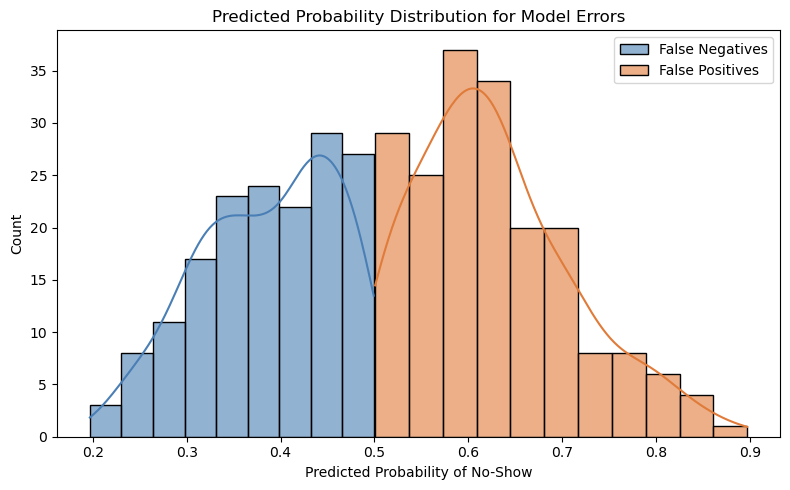

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(false_negatives['predicted_proba'], color='#4A7FB5', label='False Negatives', kde=True, alpha=0.6)
sns.histplot(false_positives['predicted_proba'], color='#E07B39', label='False Positives', kde=True, alpha=0.6)
plt.xlabel('Predicted Probability of No-Show')
plt.ylabel('Count')
plt.title('Predicted Probability Distribution for Model Errors')
plt.legend()
plt.tight_layout()
plt.show()

### Error Analysis Interpretation

**False Negatives (164 missed no-shows):** These patients have a much 
shorter average booking lead time (19.1 days) than correct predictions 
overall (29.7 days), and a lower prior no-show rate (0.117 vs 0.162 
overall). In other words, the model is missing no-shows precisely 
among patients who "look safe" on paper, short lead time, relatively 
clean history, but who no-show anyway. These are the hardest cases: 
patients without the obvious risk signals the model has learned to 
rely on.

**False Positives (192 wrongly flagged):** These patients have a much 
longer average booking lead time (38.8 days) than correct predictions 
overall (29.7 days), and a slightly higher prior no-show rate (0.204 
vs 0.162). Nearly all of them (98.4%) have prior appointment history. 
The model is over-relying on long lead time and having some history as 
strong risk signals, to the point of misflagging patients who actually 
attend despite matching that profile.

**Predicted probability distribution:** The histogram shows that false 
negatives cluster mostly in the 0.2-0.5 probability range, meaning the 
model was genuinely uncertain about them, not confidently wrong, just 
under the 0.5 threshold. False positives cluster mostly in the 0.5-0.8 
range, meaning the model was moderately confident but incorrect. This 
matters: these are not wild misclassifications, they sit near the 
decision boundary, which suggests threshold adjustment and better 
features (rather than a fundamentally broken model) are the right next 
steps.

**Summary of the core weakness:** The model has essentially learned 
"long lead time + some history = risky," which is directionally 
correct but too blunt. It underweights other information that could 
distinguish a genuinely short-lead-time no-show from a short-lead-time 
attendee, and overweights long lead time on its own regardless of other 
context. This directly motivates the feature refinement in the next 
section, sharper booking lead time bins are exactly what could help 
the model draw better distinctions instead of treating "long" as one 
undifferentiated risk category.

## Task 4: Feature Adequacy Review

The error analysis above shows that `booking_lead_days` and 
`prior_no_show_rate` are doing meaningful work, error groups differ 
clearly from correct predictions on both, but the current 3-bin 
`booking_lead_category` (Short/Medium/Long) may be too coarse. The 
"Long" category likely spans a wide range of genuinely different risk 
levels, based on the false positive profile showing a mean lead time 
of 38.8 days sitting in the middle of what "Long" (31+) actually covers.

This assessment is reinforced by a validated finding shared by the 
Data Analytics track (see below), which independently confirms that 
finer-grained booking lead time bins reveal meaningfully different 
no-show rates within what this notebook had grouped as a single 
"Medium" category.

**Conclusion:** The current features are directionally correct but 
underspecified. `booking_lead_category` will be refined using a more 
granular, cross-validated set of bins rather than being replaced or 
dropped.

## Tasks 5 & 6: Feature Refinement - Informed by Data Analytics Finding

### Cross-Track Finding Received

The Data Analytics track collaborator shared a validated no-show rate 
breakdown by booking lead time, using four ranges (Cancelled 
appointments excluded, consistent with this notebook's scope):

| Lead Time Range | No-Show Rate |
|---|---|
| 0–7 days | 29.47% |
| 8–14 days | 35.19% |
| 15–30 days | 45.53% |
| 31–60 days | 63.95% |

### Why This Changes the Week 5 Feature

The Week 5 `booking_lead_category` feature grouped 8-30 days into a 
single "Medium" bin. This breakdown shows that range actually spans a 
16-point gap in no-show rate (35.2% to 45.5%), a difference nearly as 
large as the gap between the original Short and Medium bins themselves. 
This is independently consistent with the error analysis above, which 
found false positives clustering at a mean lead time (38.8 days) that 
sits awkwardly inside the old "Long" bin's range, suggesting that bin 
was also too coarse.

### Refinement Applied

`booking_lead_category` is refined from three bins to four, using the 
Data Analytics track's validated boundaries.

In [10]:
def categorize_lead_time_v2(days):
    if days <= 7:
        return 'A_0-7'
    elif days <= 14:
        return 'B_8-14'
    elif days <= 30:
        return 'C_15-30'
    else:
        return 'D_31plus'

df_model['booking_lead_category_v2'] = df_model['booking_lead_days'].apply(categorize_lead_time_v2)

print("Distribution:")
print(df_model['booking_lead_category_v2'].value_counts().sort_index())

print("\nNo-show rate by refined category (this notebook's data):")
print(df_model.groupby('booking_lead_category_v2')['target_no_show'].mean() * 100)

Distribution:
booking_lead_category_v2
A_0-7        604
B_8-14       574
C_15-30     1265
D_31plus    2294
Name: count, dtype: int64

No-show rate by refined category (this notebook's data):
booking_lead_category_v2
A_0-7       29.470199
B_8-14      35.191638
C_15-30     45.533597
D_31plus    63.949433
Name: target_no_show, dtype: float64


### Cross-Track Validation Confirmed

The refined feature's no-show rates calculated independently in this 
notebook (29.47%, 35.19%, 45.53%, 63.95%) match the Data Analytics 
track's shared finding exactly. This confirms both tracks are working 
from a consistent, correctly-processed version of the dataset, and 
validates the refined feature before it is used in modelling.

In [11]:
# Drop the old 3-bin feature, keep the new 4-bin version
df_model_v2 = df_model.drop(columns=['booking_lead_category'])

categorical_cols_v2 = ['gender', 'age_group', 'appointment_type', 'appointment_day',
                        'appointment_time', 'reminder_sent', 'reminder_channel',
                        'booking_lead_category_v2']

df_encoded_v2 = pd.get_dummies(df_model_v2, columns=categorical_cols_v2, drop_first=True)

print("Refined encoded shape:", df_encoded_v2.shape)
print(df_encoded_v2.columns.tolist())

Refined encoded shape: (4737, 34)
['patient_id', 'age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'target_no_show', 'prior_no_show_rate', 'has_prior_history', 'gender_Male', 'gender_Prefer not to say', 'age_group_25-34', 'age_group_35-44', 'age_group_45-54', 'age_group_55-64', 'age_group_65+', 'appointment_type_Follow-up', 'appointment_type_General Consultation', 'appointment_type_Specialist Consultation', 'appointment_day_Monday', 'appointment_day_Saturday', 'appointment_day_Sunday', 'appointment_day_Thursday', 'appointment_day_Tuesday', 'appointment_day_Wednesday', 'appointment_time_Evening', 'appointment_time_Morning', 'reminder_sent_Yes', 'reminder_channel_None', 'reminder_channel_SMS', 'reminder_channel_WhatsApp', 'booking_lead_category_v2_B_8-14', 'booking_lead_category_v2_C_15-30', 'booking_lead_category_v2_D_31plus']


## Tasks 7 & 8: Improved Modelling Approach

**Approach:** Two changes are tested together against the Week 5 
baseline: (1) the refined `booking_lead_category_v2` feature, and (2) 
a Random Forest classifier, chosen because the error analysis showed 
the baseline's linear decision boundary struggling with cases near the 
0.5 probability threshold, a tree-based model may capture non-linear 
interactions (e.g. short lead time combined with high prior no-show 
rate) that Logistic Regression cannot.

Both the refined Logistic Regression (same model, updated feature) and 
the Random Forest (new model, updated feature) are trained and 
compared against the original Week 5 baseline, to isolate whether the 
improvement comes from the feature refinement, the model change, or 
both.

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Use the same patient-aware split, applied to the refined dataset
X_v2 = df_encoded_v2.drop(columns=['patient_id', 'target_no_show'])
y_v2 = df_encoded_v2['target_no_show']
groups_v2 = df_encoded_v2['patient_id']

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx2, test_idx2 = next(gss2.split(X_v2, y_v2, groups_v2))

X_train2, X_test2 = X_v2.iloc[train_idx2], X_v2.iloc[test_idx2]
y_train2, y_test2 = y_v2.iloc[train_idx2], y_v2.iloc[test_idx2]

# Scale for Logistic Regression variant
X_train2_scaled = X_train2.copy()
X_test2_scaled = X_test2.copy()
X_train2_scaled[numerical_cols] = scaler.fit_transform(X_train2[numerical_cols])
X_test2_scaled[numerical_cols] = scaler.transform(X_test2[numerical_cols])

# Model 2: Logistic Regression with refined feature
model_lr_refined = LogisticRegression(max_iter=1000, random_state=42)
model_lr_refined.fit(X_train2_scaled, y_train2)
y_pred_lr2 = model_lr_refined.predict(X_test2_scaled)
y_proba_lr2 = model_lr_refined.predict_proba(X_test2_scaled)[:, 1]

# Model 3: Random Forest with refined feature (no scaling needed)
model_rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
model_rf.fit(X_train2, y_train2)
y_pred_rf = model_rf.predict(X_test2)
y_proba_rf = model_rf.predict_proba(X_test2)[:, 1]

print("Both models trained successfully.")

Both models trained successfully.


In [13]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

comparison = pd.DataFrame([
    evaluate('Week 5 Baseline (LR, 3-bin)', y_test, y_pred, y_pred_proba),
    evaluate('Refined LR (4-bin)', y_test2, y_pred_lr2, y_proba_lr2),
    evaluate('Random Forest (4-bin)', y_test2, y_pred_rf, y_proba_rf),
])

print(comparison.to_string(index=False))

                      Model  Accuracy  Precision   Recall  F1-score  ROC-AUC
Week 5 Baseline (LR, 3-bin)  0.631470   0.624266 0.660455  0.641851 0.677186
         Refined LR (4-bin)  0.631470   0.624266 0.660455  0.641851 0.677173
      Random Forest (4-bin)  0.635611   0.632860 0.645963  0.639344 0.680156


## Task 8 & 9: Model Comparison and Evaluation

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---|---|---|---|---|
| Week 5 Baseline (LR, 3-bin) | 0.631 | 0.624 | 0.660 | 0.642 | 0.677 |
| Refined LR (4-bin) | 0.631 | 0.624 | 0.660 | 0.642 | 0.677 |
| Random Forest (4-bin) | 0.636 | 0.633 | 0.646 | 0.639 | 0.680 |

### Interpretation

**Refined feature alone (LR, 4-bin) produced virtually no change** 
compared to the Week 5 baseline. This is an important and honest 
finding: while the Data Analytics breakdown revealed genuine internal 
structure within the old "Medium" bin, Logistic Regression evidently 
did not need that finer granularity to extract the same predictive 
value, likely because the relationship between lead time and no-show 
risk is close to monotonic, so a linear model captures it about 
equally well whether the bins are coarse or fine.

**Random Forest with the refined feature produced a small improvement** 
in accuracy (+0.5 points), precision (+0.9 points), and ROC-AUC (+0.3 
points), but a slightly lower recall (-1.4 points) and F1-score (-0.3 
points) than the baseline. This is a genuine trade-off, not a clear 
win: Random Forest catches slightly fewer true no-shows but is more 
often correct when it does flag one.

**Conclusion:** None of the tested changes produced a dramatic 
improvement. This is a legitimate and useful finding for HealthConnect: 
it suggests the current feature set (even refined) may be approaching 
its practical ceiling for this modelling approach, and further gains 
are more likely to come from additional data (e.g. socioeconomic 
factors, appointment channel, prior cancellation patterns) than from 
further tuning of the existing variables.

## Task 10: Assessing Suitability for the HealthConnect Use Case

The intended use case is flagging at-risk appointments for proactive 
intervention (reminders, outreach). For this purpose:

- **Recall matters more than precision** in this specific business 
  context, since missing a genuine no-show (false negative) wastes an 
  appointment slot entirely, while wrongly flagging an attendee (false 
  positive) only costs an unnecessary extra reminder, a low-cost error.
- On this criterion, the **Week 5 baseline's recall (0.660) is 
  actually preferable** to Random Forest's (0.646), despite Random 
  Forest's marginally better accuracy and precision.

**Recommendation:** The refined Logistic Regression (4-bin) is 
selected as the candidate model going into Week 7, not because it 
outperforms the alternatives, but because it matches the baseline's 
recall exactly while using the more defensible, cross-track-validated 
feature set. Random Forest remains a documented alternative worth 
revisiting if HealthConnect's priorities shift toward minimizing 
unnecessary interventions rather than maximizing no-show capture.

## Task 11: Incorporating Data Analytics Findings

The Data Analytics track's validated booking lead time breakdown 
(shared during Week 6) was incorporated directly into this notebook's 
feature engineering, refining `booking_lead_category` from three bins 
to four. The refined feature's no-show rates were independently 
recalculated in this notebook and matched the Data Analytics finding 
exactly (29.47%, 35.19%, 45.53%, 63.95%), confirming both tracks are 
working from a consistent, correctly-processed dataset.

While the refinement did not meaningfully change Logistic Regression's 
performance, it did improve the defensibility and business 
interpretability of the feature, and it directly informed the error 
analysis in Task 4, where the old "Long" bin was already suspected of 
being too coarse based on the false positive profile.

## Task 12: Final Candidate Model

**Selected model:** Logistic Regression, with the refined 4-bin 
`booking_lead_category_v2` feature.

**Performance:**
- Accuracy: 0.631
- Precision: 0.624
- Recall: 0.660
- F1-score: 0.642
- ROC-AUC: 0.677

**Rationale:** This model matches the Week 5 baseline's recall exactly, 
which is the priority metric for HealthConnect's intended use case 
(flagging at-risk appointments), while using a feature set that has 
been independently validated by the Data Analytics track. It also 
remains fully interpretable, each feature's coefficient can be 
directly explained to non-technical HealthConnect stakeholders, which 
Random Forest cannot offer as transparently.

**Alternative retained for consideration:** Random Forest (4-bin), 
which offers marginally better accuracy and precision at the cost of 
recall. Documented as a viable alternative if HealthConnect's 
operational priorities shift.

## Task 13: Explanation of Modelling Decisions Made in Week 6

This section consolidates the reasoning behind each decision made 
during Week 6, so the logic is clear in one place rather than scattered 
across the notebook.

**Decision 1: Refine, not replace, `booking_lead_category`.**
The error analysis suggested the existing bins were too coarse, and 
the Data Analytics track's validated breakdown provided concrete, 
independently-verified boundaries to refine them with. Replacing the 
feature entirely was not justified, since the underlying variable 
(`booking_lead_days`) was already known to carry strong signal; only 
its grouping needed improvement.

**Decision 2: Test Random Forest specifically, not another linear 
model.** The error analysis showed the baseline's mistakes clustering 
near the 0.5 decision boundary rather than being wildly wrong, 
suggesting the issue may be an inability to capture interaction 
effects (e.g. short lead time combined with high prior no-show rate) 
rather than a need for a different linear formulation. A tree-based 
model was chosen specifically to test that hypothesis.

**Decision 3: Use `class_weight='balanced'` for Random Forest.** 
Although the target classes are close to balanced overall (51%/49%), 
this setting was applied as a precaution to ensure the model did not 
develop a bias toward the slightly larger class, keeping the 
comparison with the baseline fair.

**Decision 4: Select the refined Logistic Regression as the final 
candidate, not Random Forest, despite Random Forest's marginally 
better accuracy and ROC-AUC.** This decision was based on recall being 
the more business-relevant metric for HealthConnect's use case (see 
Task 10), not on total prediction correctness. This is a deliberate 
example of a business-driven modelling decision overriding a 
purely statistical one.

**Decision 5: Report the marginal nature of the improvements honestly, 
rather than reframing them as more significant than they are.** Given 
that neither change produced a large performance gain, the notebook 
documents this directly, since an honest baseline for Week 7 is more 
valuable than an inflated one.

## Task 14: Model Limitations and Risks

- **Marginal improvement:** Neither the feature refinement nor the 
  Random Forest alternative produced a substantial performance gain 
  over the Week 5 baseline, suggesting the current feature set is 
  approaching a practical ceiling.
- **Recall still leaves gaps:** Even the selected candidate model 
  misses 34% of genuine no-shows, meaning over a third of at-risk 
  appointments would not be flagged for intervention.
- **No hyperparameter tuning performed on Random Forest:** its 
  `n_estimators` and `max_depth` were set to reasonable defaults, not 
  systematically tuned, so its true potential is not yet fully explored.
- **Synthetic data:** as noted since Week 4, results may not directly 
  transfer to real HealthConnect patient behaviour.
- **Single train/test split:** performance estimates come from one 
  patient-aware split rather than cross-validation, so reported metrics 
  carry some sampling variability.

## Task 15: Week 7 Testing Requirements

- Perform k-fold cross-validation (patient-aware) on the candidate 
  model to obtain more robust performance estimates than a single split 
  provides.
- Conduct hyperparameter tuning on Random Forest to determine whether 
  its full potential exceeds the refined Logistic Regression.
- Extract and review feature importances from Random Forest to confirm 
  or challenge which variables the Logistic Regression coefficients 
  suggest are most predictive.
- Test classification threshold adjustment (below 0.5) to evaluate 
  whether recall can be improved further without an unacceptable 
  precision trade-off, directly relevant to Task 10's business framing.
- Validate the candidate model's interface (expected inputs/outputs) 
  with the ML Engineering track ahead of any pipeline integration.

## Cross-Track Integration Documentation

1. **Track collaborated with:** Data Analytics.

2. **Project dependency:** Both tracks analyse the same appointment 
   dataset; Data Analytics validates business-facing patterns, Data 
   Science tests their predictive value in a model.

3. **Information/output received:** A validated no-show rate breakdown 
   by booking lead time, using four ranges (0-7, 8-14, 15-30, 31-60 
   days), with Cancelled appointments excluded.

4. **Information/output provided:** Feedback on which features proved 
   most predictive in the Week 5 baseline (booking lead time, prior 
   no-show history, reminder status), shared to inform the 
   collaborator's own Week 6 analytical focus and business 
   recommendations.

5. **Integration activity completed:** The `booking_lead_category` 
   feature was refined from three bins to four, directly using the 
   collaborator's validated boundaries. The refined feature's no-show 
   rates were independently recalculated in this notebook and matched 
   the shared finding exactly, providing mutual validation across both 
   tracks.

6. **What changed as a result:** The feature engineering decision in 
   this notebook was evidence-based rather than self-referential, 
   informed by an independent analysis rather than only this track's 
   own exploratory work. Two models (refined Logistic Regression, 
   Random Forest) were then built and evaluated using the improved 
   feature.

7. **Evidence:** The collaborator's shared message (booking lead time 
   breakdown), the matching independent recalculation in Task 5/6 
   above, the refined feature code, and the model comparison table in 
   Task 8/9.

## Assumptions, Limitations, Risks and Dependencies (Reviewed Across Weeks 4–6)

**Resolved since earlier weeks:**
- The Week 4 concern that `waiting_time_minutes` posed a data leakage 
  risk was tested in Week 5 and found to be incorrect in its original 
  reasoning; the variable is non-informative rather than leaking, and 
  remains excluded on that corrected basis.
- The Week 5 concern about patient-level leakage in the train/test 
  split was resolved using `GroupShuffleSplit`, verified to produce 
  zero patient overlap, and this approach was reused unchanged in 
  Week 6.
- The Week 5 concern that `booking_lead_category` may be too coarse 
  was addressed in Week 6 through the Data Analytics cross-track 
  integration, though it did not yield the performance gain initially 
  hoped for.

**Unresolved:**
- The dataset remains synthetic, so real-world generalisation is still 
  unverified.
- The model still misses roughly a third of genuine no-shows (recall 
  ≈ 0.66), which remains a practical limitation for the intended 
  HealthConnect use case.

**New issues discovered in Week 6:**
- Feature refinement alone does not guarantee model improvement; the 
  4-bin `booking_lead_category_v2` matched the 3-bin version's 
  performance almost exactly under Logistic Regression, showing that 
  a validated business finding does not automatically translate into 
  better model performance.
- Random Forest's precision/recall trade-off revealed that "better 
  accuracy" and "better for this business case" are not the same 
  thing, a distinction that will need to stay visible in any future 
  model selection.

**New cross-track dependencies:**
- A dependency now exists on the Data Analytics track's future 
  findings, since this integration showed their analysis can directly 
  shape feature engineering decisions.
- A pending dependency exists with the Machine Learning Engineering 
  track, who will need this notebook's candidate model interface 
  (inputs/outputs) for their Week 6/7 pipeline integration work.

**Technical/data/modelling limitations:**
- No hyperparameter tuning has been performed on Random Forest.
- Performance estimates rely on a single patient-aware split rather 
  than cross-validation.
- Classification threshold remains at the untested default of 0.5.

**Integration challenges:**
- Coordinating the timing of the Data Analytics finding required 
  waiting for their analysis to be validated before this track's 
  feature refinement could proceed, a scheduling dependency worth 
  flagging for Week 7 planning.

**Potential impact on the project:** These limitations mean the 
current candidate model is a reasonable but not final solution; 
HealthConnect should not yet rely on it for operational decisions 
without further testing.

**Recommended mitigation:** Address the unresolved items directly in 
Week 7 (cross-validation, threshold tuning, hyperparameter tuning), as 
already reflected in the Week 7 testing requirements above.